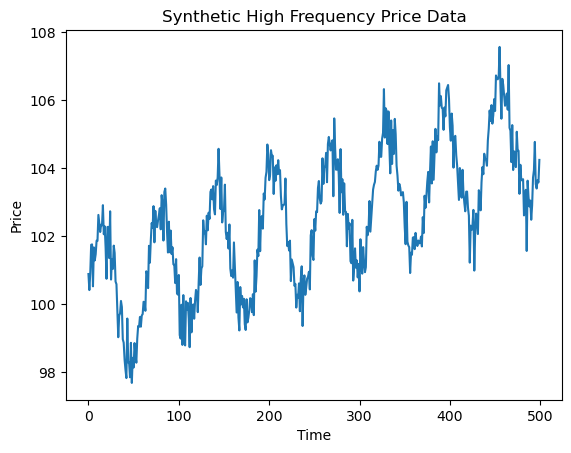

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic HFT-like price data
np.random.seed(0)
t = np.arange(0, 500)

# Price = trend + cycle + noise
price = 100 + 0.01*t + 2*np.sin(0.1*t) + np.random.normal(0, 0.5, len(t))

plt.figure()
plt.plot(t, price)
plt.title("Synthetic High Frequency Price Data")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

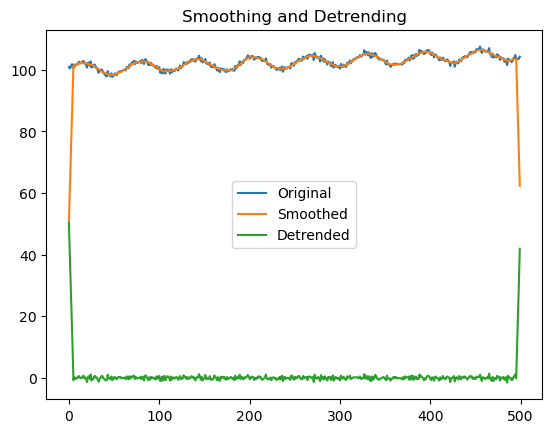

In [2]:
# Simple Moving Average (SMA)
window = 10
smooth_price = np.convolve(price, np.ones(window)/window, mode='same')

# Detrended price
detrended = price - smooth_price

plt.figure()
plt.plot(price, label='Original')
plt.plot(smooth_price, label='Smoothed')
plt.plot(detrended, label='Detrended')
plt.legend()
plt.title("Smoothing and Detrending")
plt.show()

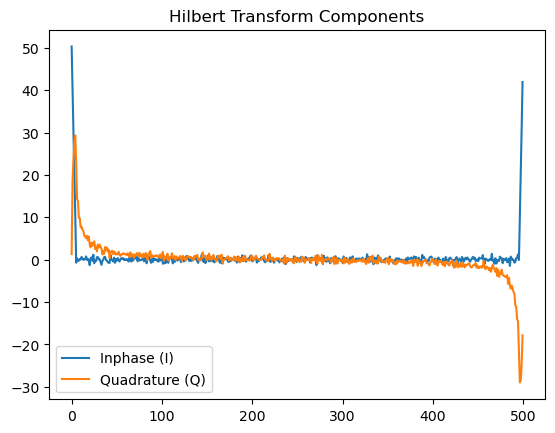

In [3]:
from scipy.signal import hilbert

analytic_signal = hilbert(detrended)

# Inphase (I) and Quadrature (Q)
I = np.real(analytic_signal)
Q = np.imag(analytic_signal)

plt.figure()
plt.plot(I, label='Inphase (I)')
plt.plot(Q, label='Quadrature (Q)')
plt.legend()
plt.title("Hilbert Transform Components")
plt.show()

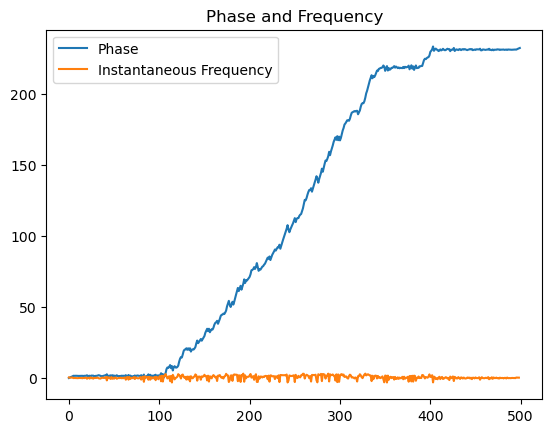

In [4]:
# Instantaneous phase
phase = np.unwrap(np.angle(analytic_signal))

# Instantaneous frequency
instant_freq = np.diff(phase)

plt.figure()
plt.plot(phase, label="Phase")
plt.plot(instant_freq, label="Instantaneous Frequency")
plt.legend()
plt.title("Phase and Frequency")
plt.show()

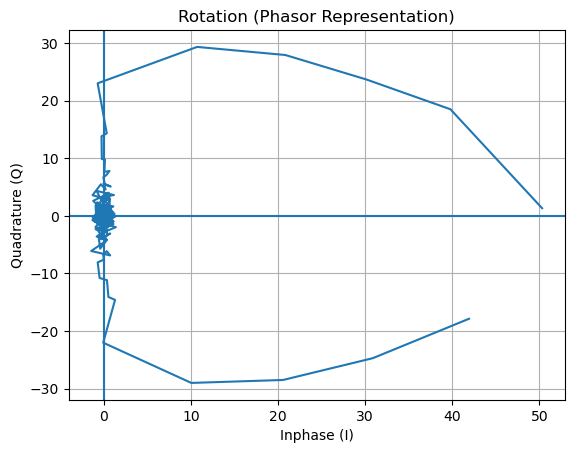

In [5]:
plt.figure()
plt.plot(I, Q)
plt.title("Rotation (Phasor Representation)")
plt.xlabel("Inphase (I)")
plt.ylabel("Quadrature (Q)")
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.show()

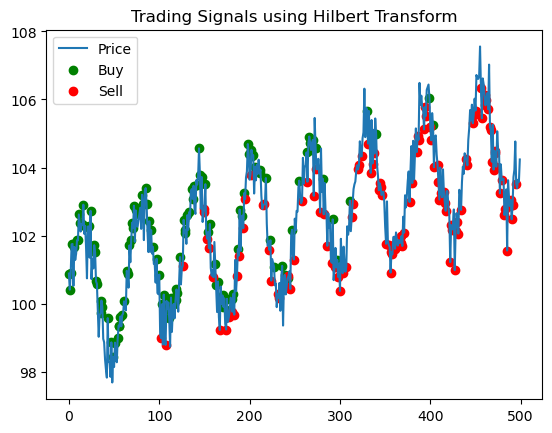

In [6]:
signals = []

for i in range(len(I)):
    if I[i] > 0 and Q[i] > 0:
        signals.append(1)   # Buy
    elif I[i] < 0 and Q[i] < 0:
        signals.append(-1)  # Sell
    else:
        signals.append(0)   # Hold

signals = np.array(signals)

plt.figure()
plt.plot(price, label='Price')
plt.scatter(t[signals==1], price[signals==1], color='green', label='Buy')
plt.scatter(t[signals==-1], price[signals==-1], color='red', label='Sell')
plt.legend()
plt.title("Trading Signals using Hilbert Transform")
plt.show()

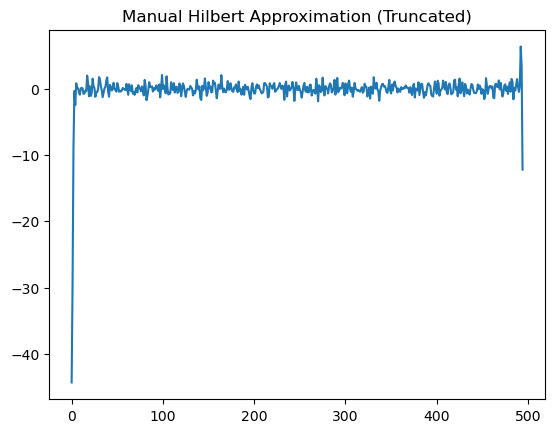

In [7]:
Q_manual = []

for i in range(5, len(detrended)):
    q = (detrended[i]/5 +
         detrended[i-1]/3 -
         detrended[i-2] -
         detrended[i-3] +
         detrended[i-4]/3 -
         detrended[i-5]/5)
    Q_manual.append(q)

plt.figure()
plt.plot(Q_manual)
plt.title("Manual Hilbert Approximation (Truncated)")
plt.show()